# Adult Census Income - Classification Project

In this notebook I am going to predict whether a person earns **more than 50K** or **less than or equal to 50K** per year using the Adult Census Income dataset.

This is a binary classification problem. I will follow all the usual steps: load data, clean it, explore it, select good features, train several models, compare them, tune the best one and finally save it.

## Cell 1 - Importing Libraries

First I import all the libraries I will need in this notebook.

In [75]:
# basic libraries
import pandas as pd
import numpy as np

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# to ignore warnings so the notebook looks clean
import warnings
warnings.filterwarnings('ignore')

# sklearn - preprocessing and model selection
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# sklearn - feature selection
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# sklearn - models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier

# sklearn - evaluation metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              roc_curve, precision_recall_curve)

# to save the trained model
import joblib

# so plots show up nicely
%matplotlib inline
sns.set_style('whitegrid')


## Cell 2 - Loading the Dataset

I am loading the CSV file that was uploaded and taking a first look at it.

In [76]:
# loading the dataset
df = pd.read_csv('adult_census_income.csv')

# first 5 rows
df.head()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [77]:
# last 5 rows
df.tail()


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [78]:
# a random sample of rows
df.sample(5, random_state=42)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
14160,29,Private,280618,Some-college,10,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,40,United-States,<=50K
27048,19,Private,439779,Some-college,10,Never-married,Sales,Own-child,White,Male,0,0,15,United-States,<=50K
28868,28,Private,204734,Some-college,10,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,40,United-States,<=50K
5667,35,Private,107991,11th,7,Never-married,Sales,Not-in-family,White,Male,0,0,45,United-States,<=50K
7827,20,Private,54152,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,?,<=50K


In [79]:
# shape of the dataset (rows, columns)
df.shape


(32561, 15)

In [80]:
# info about columns and data types
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [81]:
# statistical summary of numerical columns
df.describe()


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Cell 3 - Dataset Description

Here I am printing some basic details about the dataset like number of rows, columns, column names, data types and unique values.

In [82]:
# number of rows and columns
print('Number of rows:', df.shape[0])
print('Number of columns:', df.shape[1])


Number of rows: 32561
Number of columns: 15


In [83]:
# column names
print(df.columns.tolist())


['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']


In [84]:
# data types of each column
df.dtypes


age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object

In [85]:
# number of unique values in each column
df.nunique()


age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

In [86]:
# unique values of the target column
df['income'].unique()


array(['<=50K', '>50K'], dtype=object)

## Cell 4 - Missing Values

This dataset uses `?` to represent missing values instead of NaN. I will replace `?` with NaN first and then handle the missing values.

In [87]:
# replacing '?' with NaN so pandas can detect it as missing
df = df.replace('?', np.nan)

# missing values before cleaning
print('Missing values before cleaning:')
print(df.isnull().sum())


Missing values before cleaning:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [88]:
# the columns with missing values are categorical columns
# I am filling them with the mode (most frequent value) of each column
for col in ['workclass', 'occupation', 'native.country']:
    df[col] = df[col].fillna(df[col].mode()[0])

# missing values after cleaning
print('Missing values after cleaning:')
print(df.isnull().sum())


Missing values after cleaning:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


## Cell 5 - Duplicate Values

Checking if there are any duplicate rows in the dataset and removing them.

In [89]:
# number of duplicate rows before removing
print('Duplicate rows before:', df.duplicated().sum())


Duplicate rows before: 24


In [90]:
# dropping duplicate rows
df = df.drop_duplicates()

# checking again after removing
print('Duplicate rows after:', df.duplicated().sum())
print('New shape of dataset:', df.shape)


Duplicate rows after: 0
New shape of dataset: (32537, 15)


## Cell 6 - Exploratory Data Analysis (EDA)

Now I will explore the dataset visually to understand the distributions and relationships between the features and the target column.

### 6.1 Target Distribution

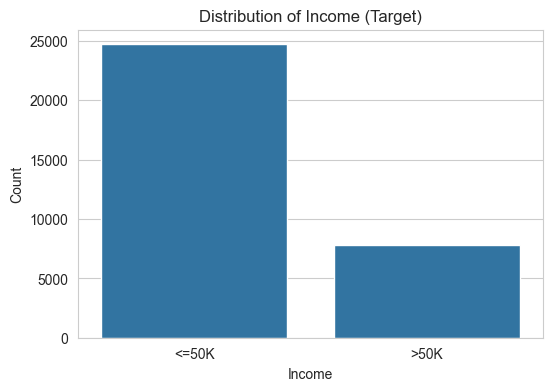

In [91]:
# distribution of the target column
plt.figure(figsize=(6,4))
sns.countplot(x='income', data=df)
plt.title('Distribution of Income (Target)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()


### 6.2 Distribution of Numerical Features (Histograms)

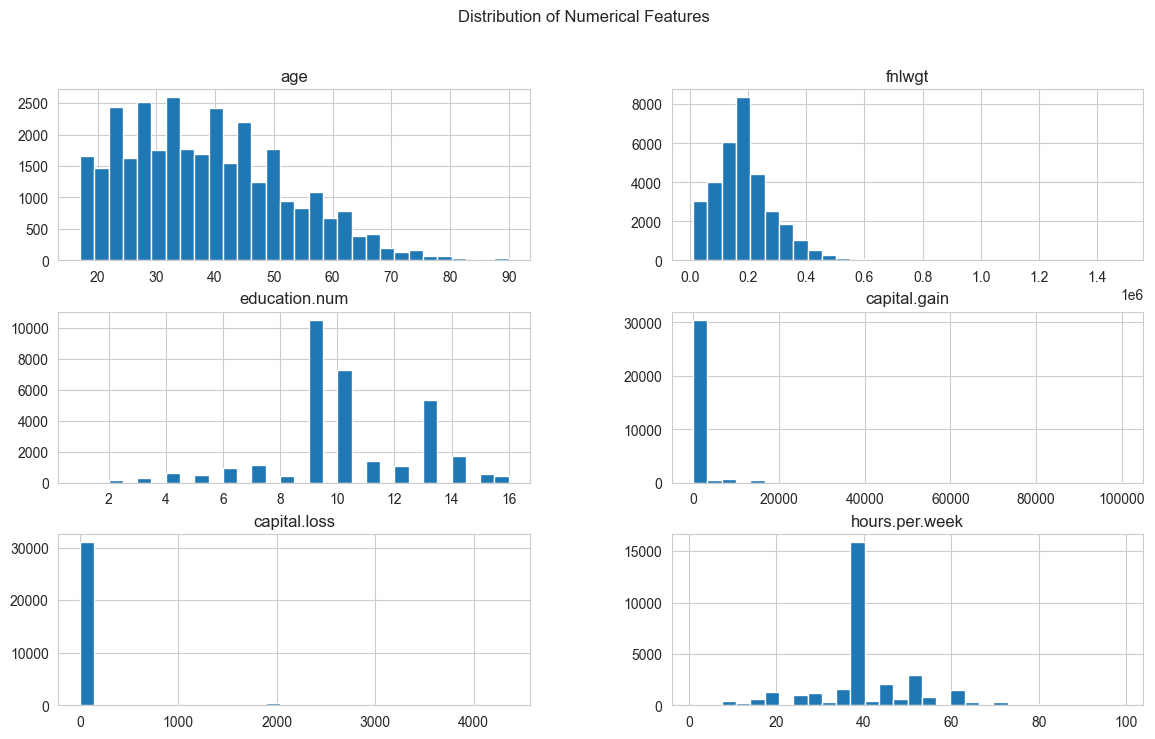

In [92]:
num_cols = ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

df[num_cols].hist(figsize=(14,8), bins=30)
plt.suptitle('Distribution of Numerical Features')
plt.show()


### 6.3 Distribution of Categorical Features (Countplots)

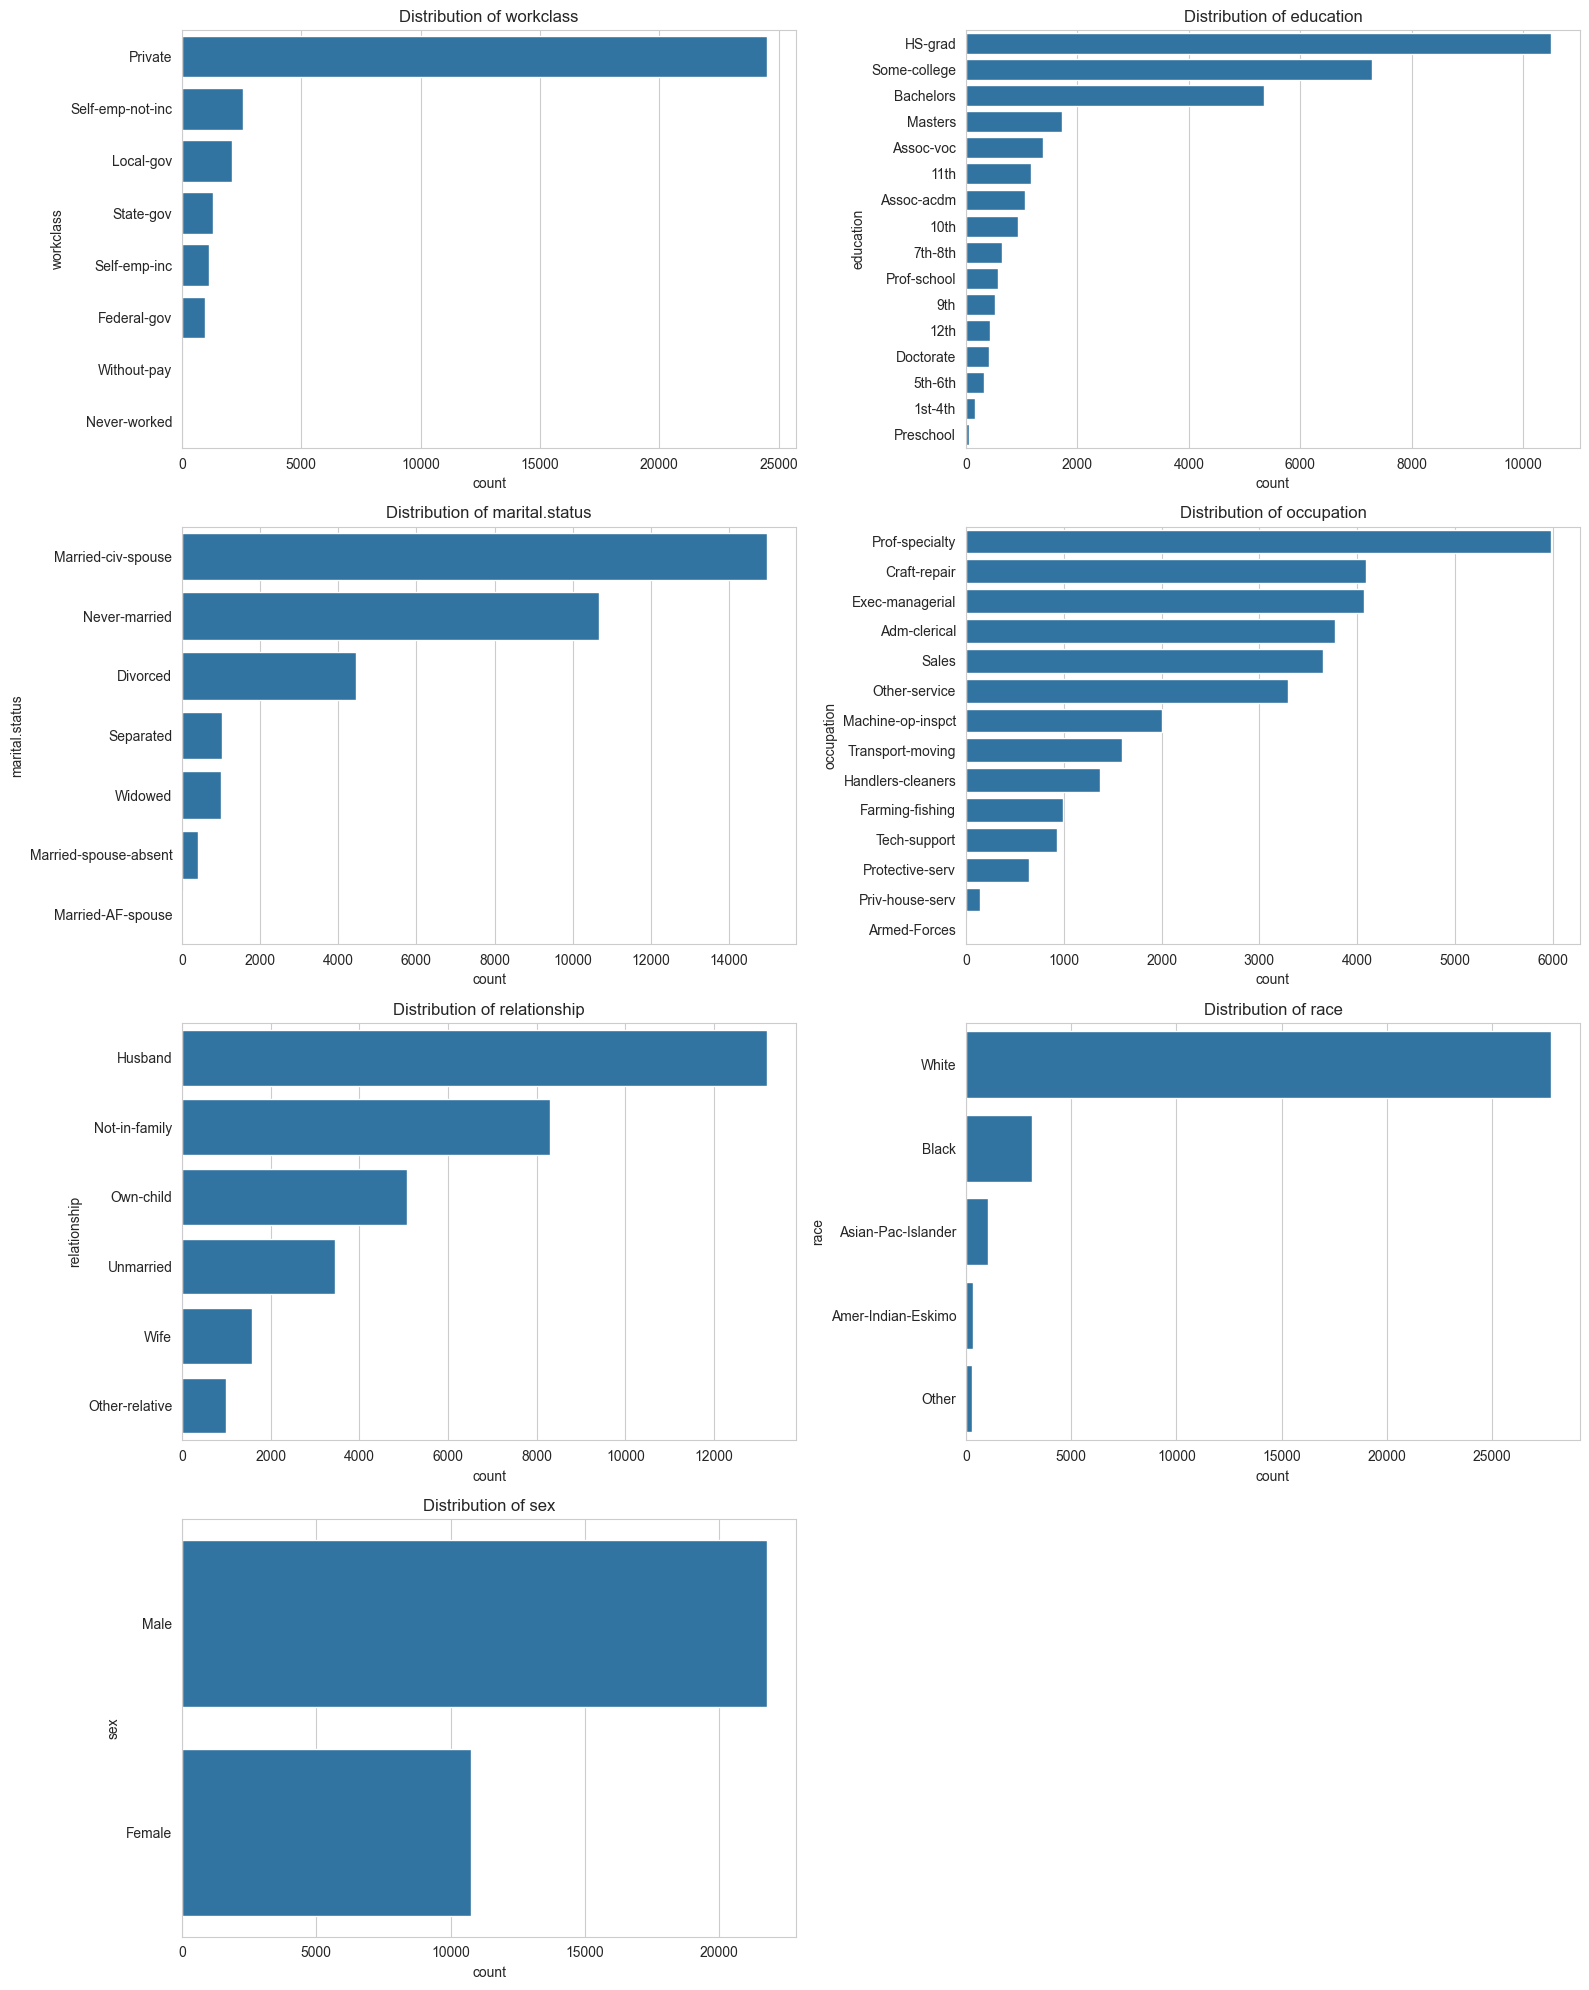

In [93]:
cat_cols = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex']

plt.figure(figsize=(16,20))
for i, col in enumerate(cat_cols):
    plt.subplot(4, 2, i+1)
    sns.countplot(y=col, data=df, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()


### 6.4 Boxplots (to check outliers in numerical columns)

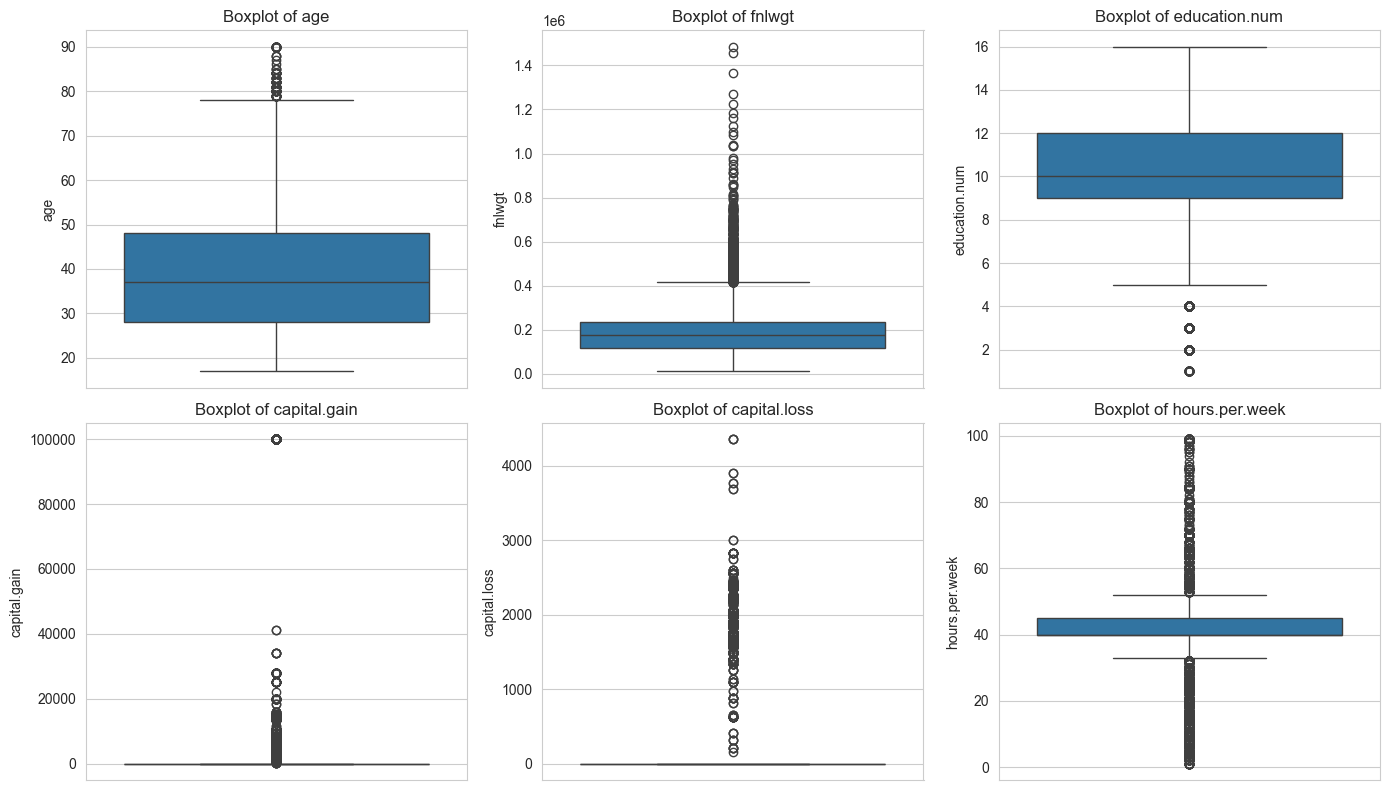

In [94]:
plt.figure(figsize=(14,8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


### 6.5 Relationship Between Important Features and Target

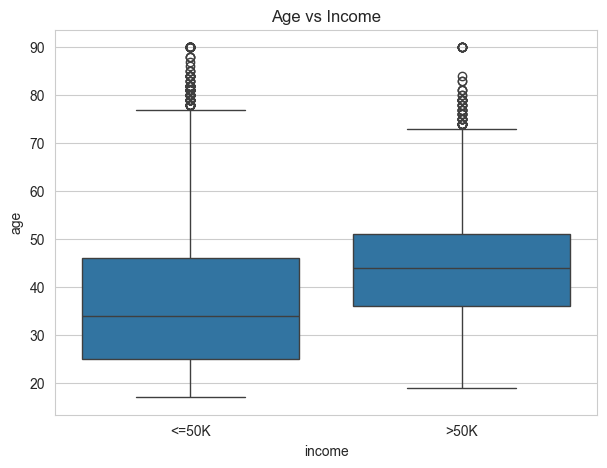

In [95]:
plt.figure(figsize=(7,5))
sns.boxplot(x='income', y='age', data=df)
plt.title('Age vs Income')
plt.show()


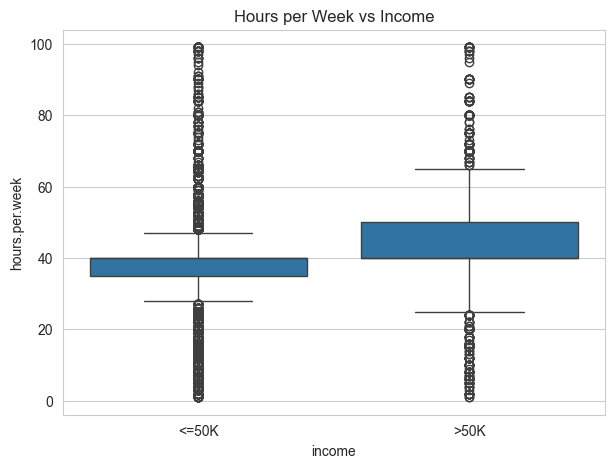

In [96]:
plt.figure(figsize=(7,5))
sns.boxplot(x='income', y='hours.per.week', data=df)
plt.title('Hours per Week vs Income')
plt.show()


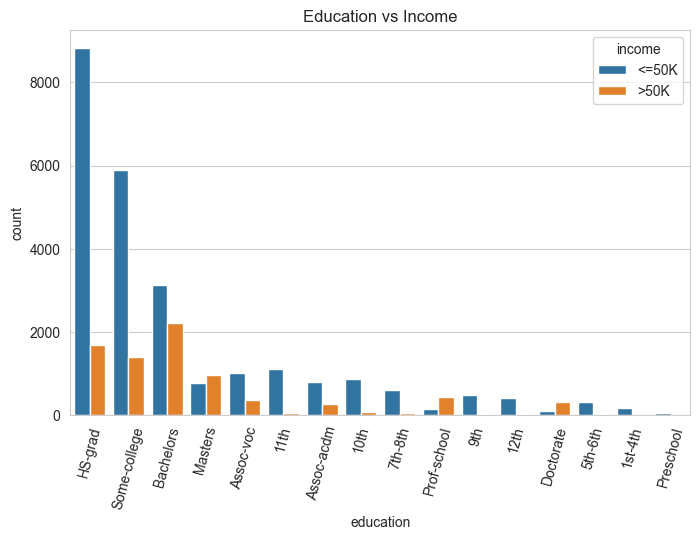

In [97]:
plt.figure(figsize=(8,5))
sns.countplot(x='education', hue='income', data=df, order=df['education'].value_counts().index)
plt.title('Education vs Income')
plt.xticks(rotation=75)
plt.show()


### 6.6 Scatter Plot

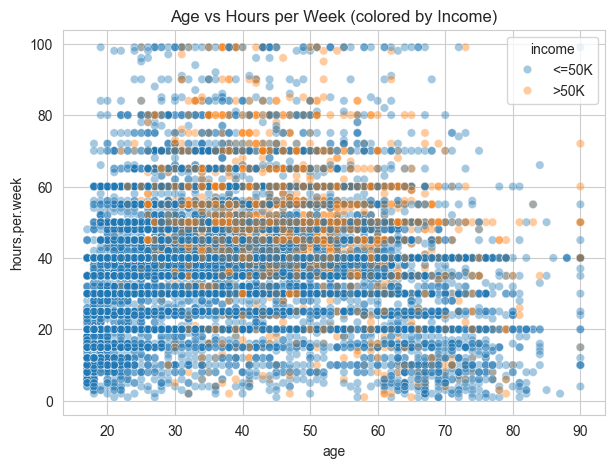

In [98]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='age', y='hours.per.week', hue='income', data=df, alpha=0.4)
plt.title('Age vs Hours per Week (colored by Income)')
plt.show()


### 6.7 Pairplot of Numerical Features

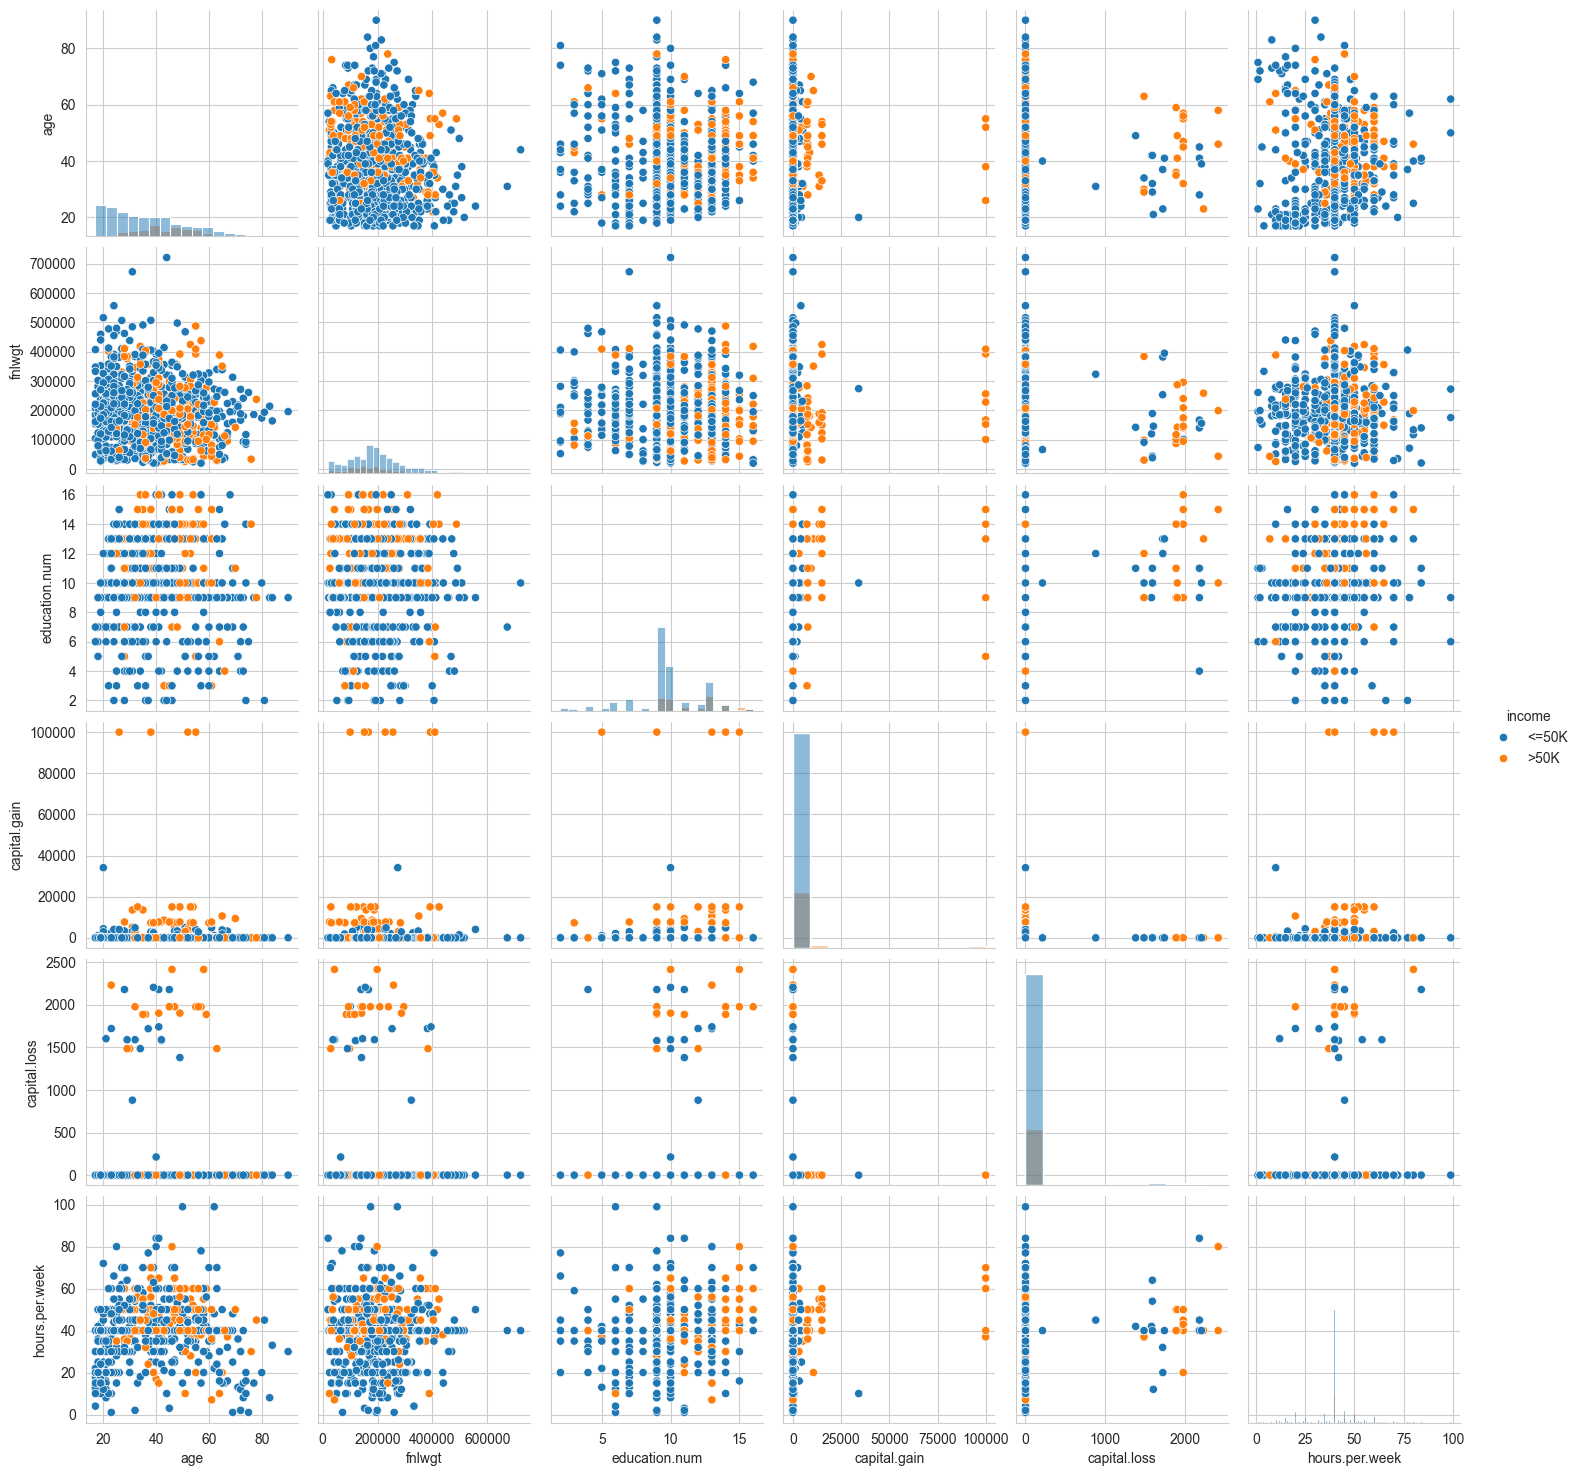

In [99]:
# using a sample of the data because pairplot is slow on the full dataset
sample_df = df.sample(1000, random_state=42)
sns.pairplot(sample_df[num_cols + ['income']], hue='income', diag_kind='hist')
plt.show()


### 6.8 Correlation Heatmap

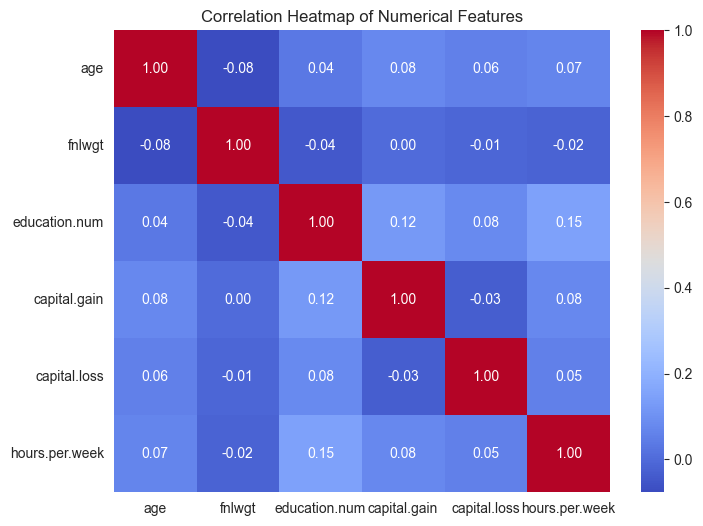

In [100]:
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()


## Cell 7 - Encoding

Machine learning models need numbers, not text. So I will convert the categorical columns into numbers.

For the target column `income` I use simple label mapping (0 = <=50K, 1 = >50K). For the other categorical columns I use One-Hot Encoding.

In [101]:
print(df_encoded.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income             int64
dtype: object


In [102]:
df_encoded = df.copy()

# encoding target column manually: 0 = <=50K, 1 = >50K
df_encoded['income'] = df_encoded['income'].map({'<=50K': 0, '>50K': 1})

# finding all categorical columns automatically (excluding target)
cat_cols_all = df_encoded.select_dtypes(include=['object']).columns.tolist()

print("Categorical columns to encode:", cat_cols_all)

Categorical columns to encode: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


In [103]:
# one hot encoding the categorical columns
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols_all, drop_first=True)

print('Shape after encoding:', df_encoded.shape)
df_encoded.head()


Shape after encoding: (32537, 98)


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,income,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,native.country_Portugal,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia
0,90,77053,9,0,4356,40,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
1,82,132870,9,0,4356,18,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
2,66,186061,10,0,4356,40,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,54,140359,4,0,3900,40,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False
4,41,264663,10,0,3900,40,0,False,False,True,...,False,False,False,False,False,False,False,True,False,False


## Cell 8 - Feature Selection

The dataset has a lot of columns after one-hot encoding. I will use 4 different techniques to find the most useful features and then use only those features to train the models.

1. SelectKBest (ANOVA F-test)
2. Mutual Information
3. Feature Importance from Decision Tree
4. Feature Importance from Random Forest

In [104]:
# splitting into all features (X_all) and target (y_all) before feature selection
X_all = df_encoded.drop('income', axis=1)
y_all = df_encoded['income']


### 8.1 SelectKBest (ANOVA F-test)

In [105]:
selector = SelectKBest(score_func=f_classif, k=15)
selector.fit(X_all, y_all)

kbest_scores = pd.Series(selector.scores_, index=X_all.columns).sort_values(ascending=False)
print('Top 15 features by SelectKBest:')
kbest_scores.head(15)


Top 15 features by SelectKBest:


marital.status_Married-civ-spouse    8016.009924
education.num                        4120.313326
marital.status_Never-married         3667.499422
age                                  1885.316441
hours.per.week                       1811.533866
relationship_Own-child               1793.852400
capital.gain                         1708.013854
sex_Male                             1591.763761
occupation_Exec-managerial           1575.109853
relationship_Not-in-family           1195.987860
education_Bachelors                  1096.139253
education_Masters                    1023.866550
occupation_Other-service              815.065133
education_Prof-school                 799.868289
capital.loss                          754.012116
dtype: float64

### 8.2 Mutual Information

In [106]:
mi_scores = mutual_info_classif(X_all, y_all, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_all.columns).sort_values(ascending=False)
print('Top 15 features by Mutual Information:')
mi_scores.head(15)


Top 15 features by Mutual Information:


marital.status_Married-civ-spouse    0.107802
capital.gain                         0.080189
age                                  0.066591
education.num                        0.063730
marital.status_Never-married         0.063188
hours.per.week                       0.039859
capital.loss                         0.039441
relationship_Own-child               0.036315
fnlwgt                               0.033847
sex_Male                             0.028113
occupation_Exec-managerial           0.021065
relationship_Not-in-family           0.020008
education_Bachelors                  0.016658
occupation_Other-service             0.014427
relationship_Unmarried               0.012965
dtype: float64

### 8.3 Feature Importance using Decision Tree

In [107]:
dt_fs = DecisionTreeClassifier(random_state=42)
dt_fs.fit(X_all, y_all)

dt_importance = pd.Series(dt_fs.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print('Top 15 features by Decision Tree:')
dt_importance.head(15)


Top 15 features by Decision Tree:


marital.status_Married-civ-spouse    0.197694
fnlwgt                               0.194941
education.num                        0.114219
age                                  0.111566
capital.gain                         0.105458
hours.per.week                       0.065980
capital.loss                         0.039320
occupation_Exec-managerial           0.010601
workclass_Private                    0.009852
occupation_Craft-repair              0.009180
workclass_Self-emp-not-inc           0.008529
occupation_Sales                     0.007962
occupation_Prof-specialty            0.006755
workclass_Local-gov                  0.006623
occupation_Transport-moving          0.006239
dtype: float64

### 8.4 Feature Importance using Random Forest

In [108]:
rf_fs = RandomForestClassifier(n_estimators=100, random_state=42)
rf_fs.fit(X_all, y_all)

rf_importance = pd.Series(rf_fs.feature_importances_, index=X_all.columns).sort_values(ascending=False)
print('Top 15 features by Random Forest:')
rf_importance.head(15)


Top 15 features by Random Forest:


fnlwgt                               0.170027
age                                  0.156223
capital.gain                         0.095562
hours.per.week                       0.086567
marital.status_Married-civ-spouse    0.084814
education.num                        0.070990
marital.status_Never-married         0.033736
capital.loss                         0.032548
occupation_Exec-managerial           0.019958
relationship_Not-in-family           0.017536
sex_Male                             0.016981
workclass_Private                    0.011426
relationship_Own-child               0.010561
education_Bachelors                  0.010381
occupation_Prof-specialty            0.010074
dtype: float64

### 8.5 Feature Importance Bar Chart

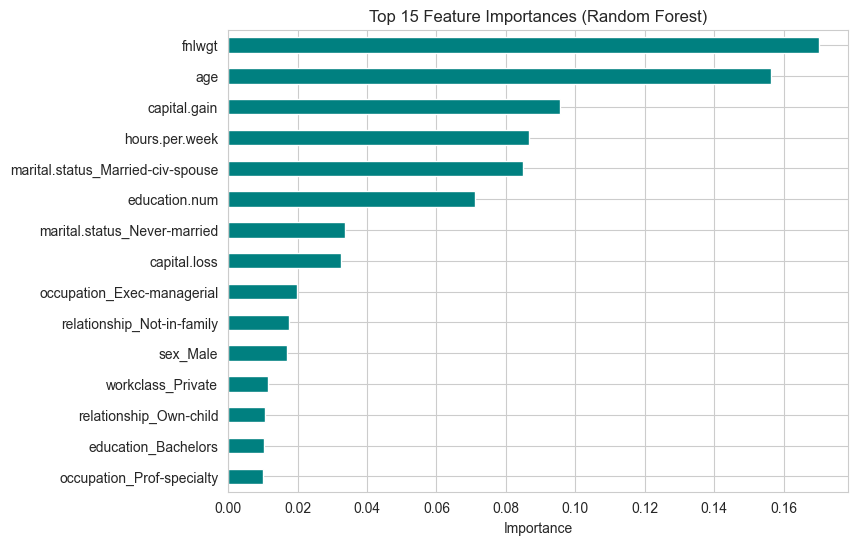

In [109]:
plt.figure(figsize=(8,6))
rf_importance.head(15).sort_values().plot(kind='barh', color='teal')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.show()


### 8.6 Selected Features

All four methods agree that features like `age`, `education.num`, `capital.gain`, `hours.per.week` and `marital.status_Married-civ-spouse` are among the most important ones. I am going to go with the top 15 features from the Random Forest importance since Random Forest captures both linear and non-linear relationships.

In [110]:
selected_features = rf_importance.head(15).index.tolist()
print('Selected Features:')
selected_features


Selected Features:


['fnlwgt',
 'age',
 'capital.gain',
 'hours.per.week',
 'marital.status_Married-civ-spouse',
 'education.num',
 'marital.status_Never-married',
 'capital.loss',
 'occupation_Exec-managerial',
 'relationship_Not-in-family',
 'sex_Male',
 'workclass_Private',
 'relationship_Own-child',
 'education_Bachelors',
 'occupation_Prof-specialty']

## Cell 9 - Split Features and Target

Now I create the final X and y using only the selected features from Cell 8.

In [111]:
X = df_encoded[selected_features]
y = df_encoded['income']

print(X.shape)
print(y.shape)


(32537, 15)
(32537,)


## Cell 10 - Train-Test Split

Splitting the data into training set and testing set. I use 80% for training and 20% for testing.

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)


X_train shape: (26029, 15)
X_test shape: (6508, 15)


## Cell 11 - Feature Scaling

Some models like Logistic Regression, KNN, Naive Bayes and SVM work better when the features are scaled. Tree based models (Decision Tree, Random Forest, Bagging, AdaBoost, Gradient Boosting) do not need scaling, so I will keep a separate scaled version only for the models that need it.

In [113]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting back to dataframe so column names are kept
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_scaled.head()


,fnlwgt,age,capital.gain,hours.per.week,marital.status_Married-civ-spouse,education.num,marital.status_Never-married,capital.loss,occupation_Exec-managerial,relationship_Not-in-family,sex_Male,workclass_Private,relationship_Own-child,education_Bachelors,occupation_Prof-specialty
0,-0.470627,-1.285119,-0.146741,-1.663470,-0.923077,-0.031109,1.424586,-0.217980,-0.377192,-0.584848,0.701775,0.569527,2.324817,-0.443053,2.104906
1,2.306554,0.183261,0.440673,1.592035,1.083334,0.357626,-0.701958,-0.217980,-0.377192,-0.584848,0.701775,0.569527,-0.430141,-0.443053,-0.475081
2,0.492384,-1.064862,-0.146741,-0.035717,-0.923077,-0.419844,1.424586,-0.217980,-0.377192,-0.584848,-1.424958,0.569527,-0.430141,-0.443053,-0.475081
3,-0.856828,1.504803,-0.146741,-1.826245,-0.923077,-0.419844,-0.701958,-0.217980,-0.377192,1.709847,-1.424958,0.569527,-0.430141,-0.443053,2.104906
4,0.737201,-0.257253,-0.146741,0.778159,1.083334,-0.419844,-0.701958,4.422739,-0.377192,-0.584848,0.701775,0.569527,-0.430141,-0.443053,-0.475081


## Cell 12 - Training All Classification Models

I am training 9 different classification models. I am storing each model in a dictionary called `models` along with a flag that tells whether that model uses the scaled data or the normal data.

### 12.1 Logistic Regression

In [114]:
models = {}

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, True)   # True = uses scaled data

print('Logistic Regression trained')


Logistic Regression trained


### 12.2 K-Nearest Neighbors

In [115]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
models['KNN'] = (knn, True)

print('KNN trained')


KNN trained


### 12.3 Gaussian Naive Bayes

In [116]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
models['Naive Bayes'] = (nb, True)

print('Naive Bayes trained')


Naive Bayes trained


### 12.4 Support Vector Machine

In [117]:
svm = SVC(probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)
models['SVM'] = (svm, True)

print('SVM trained')


SVM trained


### 12.5 Decision Tree Classifier

In [118]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = (dt, False)   # False = uses normal (unscaled) data

print('Decision Tree trained')


Decision Tree trained


### 12.6 Bagging Classifier

In [119]:
bag = BaggingClassifier(random_state=42)
bag.fit(X_train, y_train)
models['Bagging'] = (bag, False)

print('Bagging trained')


Bagging trained


### 12.7 AdaBoost Classifier

In [120]:
ada = AdaBoostClassifier(random_state=42)
ada.fit(X_train, y_train)
models['AdaBoost'] = (ada, False)

print('AdaBoost trained')


AdaBoost trained


### 12.8 Gradient Boosting Classifier

In [121]:
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)
models['Gradient Boosting'] = (gb, False)

print('Gradient Boosting trained')


Gradient Boosting trained


### 12.9 Random Forest Classifier

In [122]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, False)

print('Random Forest trained')


Random Forest trained


## Cell 13 - Model Evaluation

Now I will evaluate every single model on the test set using Accuracy, Precision, Recall, F1-score, ROC AUC, Confusion Matrix, Classification Report, ROC Curve and Precision-Recall Curve.

In [123]:
# a dictionary to store the metrics of every model, will be used in Cell 14
metrics_store = {}

for name, (model, scaled) in models.items():
    Xte = X_test_scaled if scaled else X_test
    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    metrics_store[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1, 'ROC AUC': auc}

    print('=====', name, '=====')
    print('Accuracy :', round(acc,4))
    print('Precision:', round(prec,4))
    print('Recall   :', round(rec,4))
    print('F1-score :', round(f1,4))
    print('ROC AUC  :', round(auc,4))
    print()


===== Logistic Regression =====
Accuracy : 0.8445
Precision: 0.729
Recall   : 0.5644
F1-score : 0.6362
ROC AUC  : 0.8922

===== KNN =====
Accuracy : 0.825
Precision: 0.6581
Recall   : 0.5695
F1-score : 0.6106
ROC AUC  : 0.844

===== Naive Bayes =====
Accuracy : 0.8193
Precision: 0.6153
Recall   : 0.6671
F1-score : 0.6401
ROC AUC  : 0.8713

===== SVM =====
Accuracy : 0.8442
Precision: 0.7368
Recall   : 0.5497
F1-score : 0.6297
ROC AUC  : 0.8838

===== Decision Tree =====
Accuracy : 0.8047
Precision: 0.5946
Recall   : 0.595
F1-score : 0.5948
ROC AUC  : 0.7331

===== Bagging =====
Accuracy : 0.8391
Precision: 0.7024
Recall   : 0.5765
F1-score : 0.6333
ROC AUC  : 0.8657

===== AdaBoost =====
Accuracy : 0.8476
Precision: 0.7376
Recall   : 0.5702
F1-score : 0.6432
ROC AUC  : 0.8979

===== Gradient Boosting =====
Accuracy : 0.8574
Precision: 0.7735
Recall   : 0.5772
F1-score : 0.6611
ROC AUC  : 0.9122

===== Random Forest =====
Accuracy : 0.8425
Precision: 0.7037
Recall   : 0.5982
F1-score : 

===== Logistic Regression =====
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      4940
           1       0.73      0.56      0.64      1568

    accuracy                           0.84      6508
   macro avg       0.80      0.75      0.77      6508
weighted avg       0.84      0.84      0.84      6508



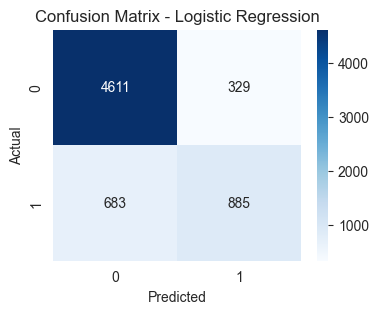

===== KNN =====
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4940
           1       0.66      0.57      0.61      1568

    accuracy                           0.82      6508
   macro avg       0.76      0.74      0.75      6508
weighted avg       0.82      0.82      0.82      6508



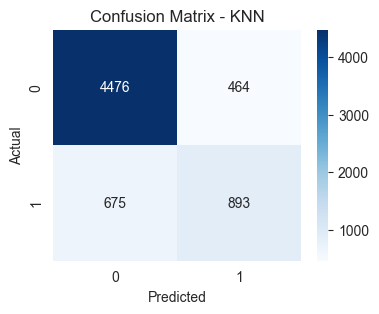

===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4940
           1       0.62      0.67      0.64      1568

    accuracy                           0.82      6508
   macro avg       0.75      0.77      0.76      6508
weighted avg       0.82      0.82      0.82      6508



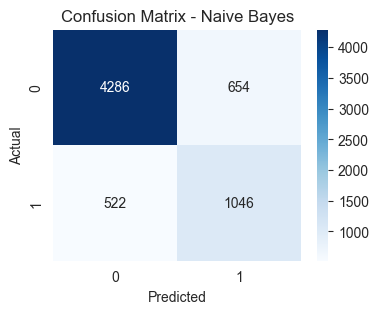

===== SVM =====
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4940
           1       0.74      0.55      0.63      1568

    accuracy                           0.84      6508
   macro avg       0.80      0.74      0.77      6508
weighted avg       0.84      0.84      0.84      6508



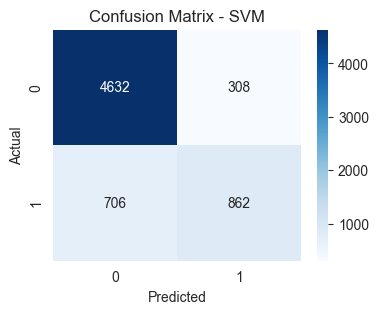

===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4940
           1       0.59      0.60      0.59      1568

    accuracy                           0.80      6508
   macro avg       0.73      0.73      0.73      6508
weighted avg       0.80      0.80      0.80      6508



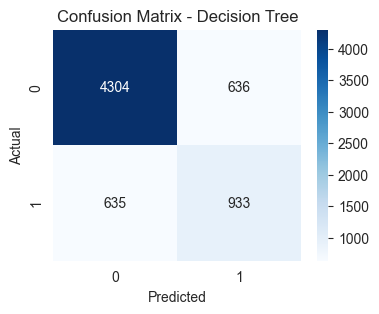

===== Bagging =====
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      4940
           1       0.70      0.58      0.63      1568

    accuracy                           0.84      6508
   macro avg       0.79      0.75      0.77      6508
weighted avg       0.83      0.84      0.83      6508



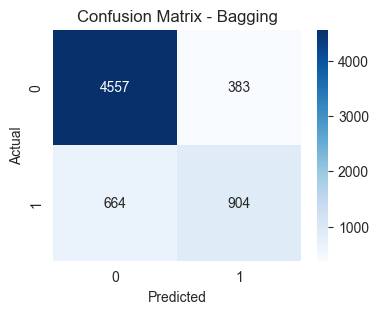

===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      4940
           1       0.74      0.57      0.64      1568

    accuracy                           0.85      6508
   macro avg       0.81      0.75      0.77      6508
weighted avg       0.84      0.85      0.84      6508



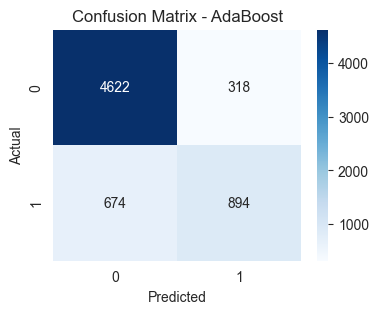

===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4940
           1       0.77      0.58      0.66      1568

    accuracy                           0.86      6508
   macro avg       0.82      0.76      0.79      6508
weighted avg       0.85      0.86      0.85      6508



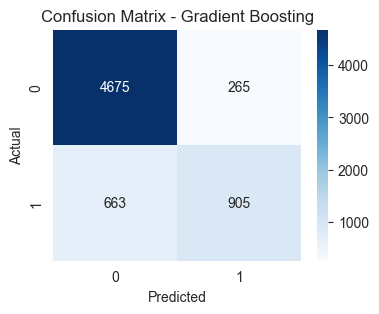

===== Random Forest =====
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4940
           1       0.70      0.60      0.65      1568

    accuracy                           0.84      6508
   macro avg       0.79      0.76      0.77      6508
weighted avg       0.84      0.84      0.84      6508



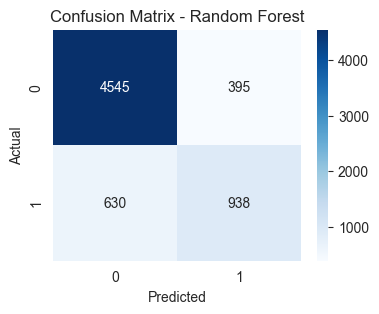

In [124]:
# confusion matrix and classification report for every model
for name, (model, scaled) in models.items():
    Xte = X_test_scaled if scaled else X_test
    y_pred = model.predict(Xte)

    print('=====', name, '=====')
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


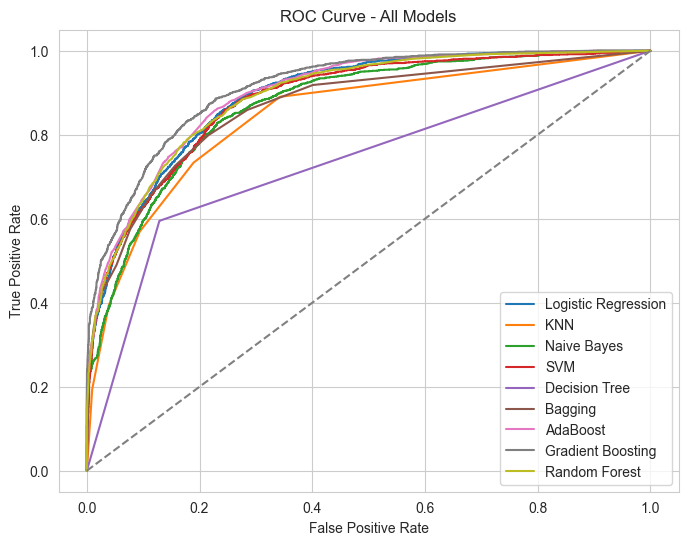

In [125]:
# ROC curve for all models on one plot
plt.figure(figsize=(8,6))
for name, (model, scaled) in models.items():
    Xte = X_test_scaled if scaled else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - All Models')
plt.legend()
plt.show()


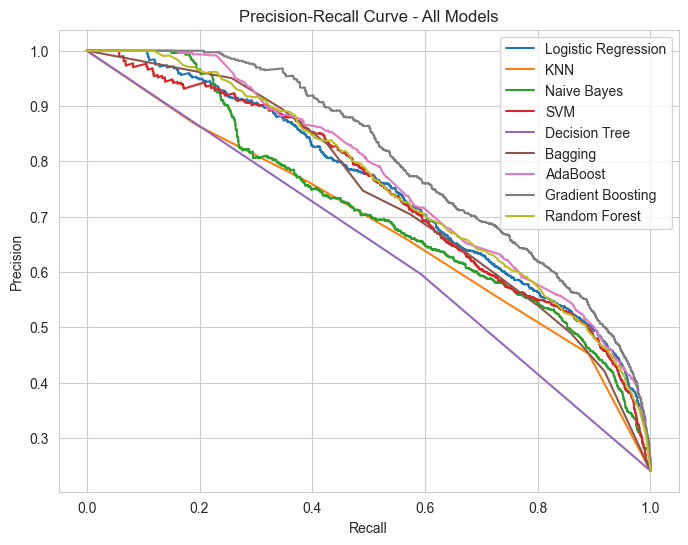

In [126]:
# Precision-Recall curve for all models on one plot
plt.figure(figsize=(8,6))
for name, (model, scaled) in models.items():
    Xte = X_test_scaled if scaled else X_test
    y_proba = model.predict_proba(Xte)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(recall, precision, label=name)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - All Models')
plt.legend()
plt.show()


## Cell 14 - Model Comparison

Now I put the accuracy of every model into a dictionary called `results`, and all the metrics into a dataframe called `comparison_df`.

In [127]:
results = {name: metrics_store[name]['Accuracy'] for name in metrics_store}
results


{'Logistic Regression': 0.844499078057775,
 'KNN': 0.8249846342962508,
 'Naive Bayes': 0.819299323909035,
 'SVM': 0.8441917639827904,
 'Decision Tree': 0.8047019053472649,
 'Bagging': 0.8391210817455439,
 'AdaBoost': 0.8475722188076213,
 'Gradient Boosting': 0.8574062692071297,
 'Random Forest': 0.842501536570375}

In [128]:
comparison_df = pd.DataFrame(metrics_store).T
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)
comparison_df


,Accuracy,Precision,Recall,F1-score,ROC AUC
Gradient Boosting,0.857406,0.773504,0.577168,0.661066,0.912152
AdaBoost,0.847572,0.737624,0.570153,0.643165,0.897887
Logistic Regression,0.844499,0.728995,0.564413,0.636233,0.892207
SVM,0.844192,0.736752,0.549745,0.629657,0.883766
Random Forest,0.842502,0.703676,0.598214,0.646674,0.891420
Bagging,0.839121,0.702409,0.576531,0.633275,0.865730
KNN,0.824985,0.658069,0.569515,0.610598,0.844006
Naive Bayes,0.819299,0.615294,0.667092,0.640147,0.871291
Decision Tree,0.804702,0.594646,0.595026,0.594836,0.733099


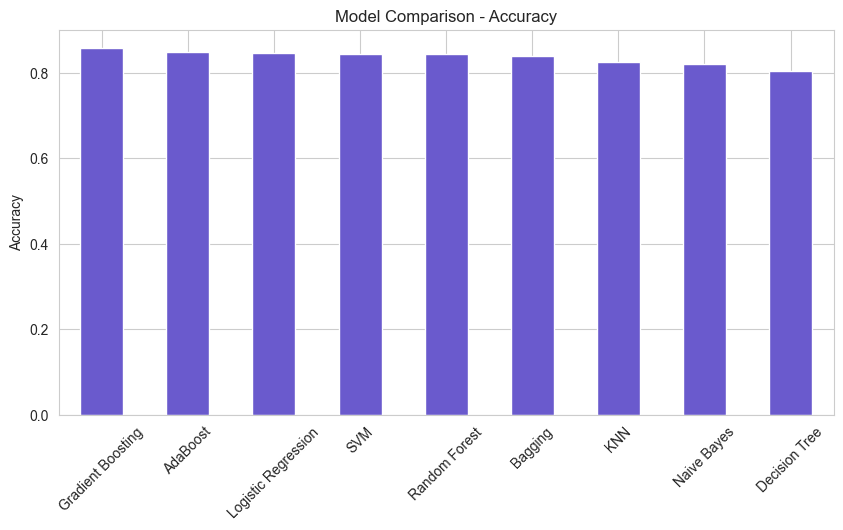

In [129]:
# comparison bar chart
comparison_df['Accuracy'].plot(kind='bar', figsize=(10,5), color='slateblue')
plt.title('Model Comparison - Accuracy')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()


## Cell 15 - Best Model

Picking the best model automatically based on the highest accuracy in `comparison_df`.

In [130]:
best_model_name = comparison_df.index[0]
print('Best Model:', best_model_name)
print('Best Accuracy:', comparison_df.loc[best_model_name, 'Accuracy'])


Best Model: Gradient Boosting
Best Accuracy: 0.8574062692071297


## Cell 16 - Hyperparameter Tuning

Now I will tune the best model using both GridSearchCV and RandomizedSearchCV, and compare the results before and after tuning.

In [131]:
# getting the correct train/test data depending on whether the best model needs scaling
scaled_flag = models[best_model_name][1]
X_train_final = X_train_scaled if scaled_flag else X_train
X_test_final = X_test_scaled if scaled_flag else X_test

accuracy_before_tuning = comparison_df.loc[best_model_name, 'Accuracy']
print('Accuracy before tuning:', accuracy_before_tuning)


Accuracy before tuning: 0.8574062692071297


In [132]:
# setting up a small parameter grid depending on which model is the best one
# (keeping the grid small so the notebook does not take too long to run)

if best_model_name == 'Random Forest':
    param_grid = {'n_estimators': [100, 200], 'max_depth': [10, 20, None]}
    base_model = RandomForestClassifier(random_state=42)

elif best_model_name == 'Gradient Boosting':
    param_grid = {'n_estimators': [100, 150], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]}
    base_model = GradientBoostingClassifier(random_state=42)

elif best_model_name == 'AdaBoost':
    param_grid = {'n_estimators': [50, 100], 'learning_rate': [0.5, 1.0]}
    base_model = AdaBoostClassifier(random_state=42)

elif best_model_name == 'Bagging':
    param_grid = {'n_estimators': [10, 50], 'max_samples': [0.5, 1.0]}
    base_model = BaggingClassifier(random_state=42)

elif best_model_name == 'Decision Tree':
    param_grid = {'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]}
    base_model = DecisionTreeClassifier(random_state=42)

elif best_model_name == 'Logistic Regression':
    param_grid = {'C': [0.01, 0.1, 1, 10]}
    base_model = LogisticRegression(random_state=42, max_iter=1000)

elif best_model_name == 'SVM':
    param_grid = {'C': [0.1, 1, 10], 'kernel': ['rbf', 'linear']}
    base_model = SVC(probability=True, random_state=42)

elif best_model_name == 'KNN':
    param_grid = {'n_neighbors': [3, 5, 7, 9]}
    base_model = KNeighborsClassifier()

else:  # Naive Bayes has basically nothing to tune
    param_grid = {'var_smoothing': [1e-9, 1e-8, 1e-7]}
    base_model = GaussianNB()

print('Base model:', base_model)
print('Param grid:', param_grid)


Base model: GradientBoostingClassifier(random_state=42)
Param grid: {'n_estimators': [100, 150], 'max_depth': [2, 3], 'learning_rate': [0.05, 0.1]}


### 16.1 GridSearchCV

In [133]:
grid_search = GridSearchCV(base_model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_final, y_train)

print('Best Parameters (Grid):', grid_search.best_params_)
print('Best Score (Grid):', grid_search.best_score_)
print('Best Estimator (Grid):', grid_search.best_estimator_)


Best Parameters (Grid): {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 150}
Best Score (Grid): 0.864574070894902
Best Estimator (Grid): GradientBoostingClassifier(n_estimators=150, random_state=42)


### 16.2 RandomizedSearchCV

In [134]:
random_search = RandomizedSearchCV(base_model, param_grid, cv=3, scoring='accuracy', n_iter=5, random_state=42, n_jobs=-1)
random_search.fit(X_train_final, y_train)

print('Best Parameters (Random):', random_search.best_params_)
print('Best Score (Random):', random_search.best_score_)
print('Best Estimator (Random):', random_search.best_estimator_)


Best Parameters (Random): {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.1}
Best Score (Random): 0.864574070894902
Best Estimator (Random): GradientBoostingClassifier(n_estimators=150, random_state=42)


### 16.3 Before vs After Tuning

In [135]:
tuning_comparison = pd.DataFrame({
    'Stage': ['Before Tuning', 'After GridSearchCV', 'After RandomizedSearchCV'],
    'Accuracy': [accuracy_before_tuning, grid_search.best_score_, random_search.best_score_]
})
tuning_comparison


,Stage,Accuracy
0,Before Tuning,0.857406
1,After GridSearchCV,0.864574
2,After RandomizedSearchCV,0.864574


In [136]:
# picking the final model - whichever search gave the better cross validation score
if grid_search.best_score_ >= random_search.best_score_:
    final_model = grid_search.best_estimator_
    print('Using the GridSearchCV model as the final model')
else:
    final_model = random_search.best_estimator_
    print('Using the RandomizedSearchCV model as the final model')


Using the GridSearchCV model as the final model


## Cell 17 - Evaluating the Tuned Best Model

Now evaluating the final tuned model on the test set.

In [137]:
y_pred_final = final_model.predict(X_test_final)
y_proba_final = final_model.predict_proba(X_test_final)[:, 1]

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(y_test, y_pred_final)
final_recall = recall_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_proba_final)

print('Final Accuracy :', round(final_accuracy,4))
print('Final Precision:', round(final_precision,4))
print('Final Recall   :', round(final_recall,4))
print('Final F1-score :', round(final_f1,4))
print('Final ROC AUC  :', round(final_auc,4))


Final Accuracy : 0.8612
Final Precision: 0.7782
Final Recall   : 0.5931
Final F1-score : 0.6732
Final ROC AUC  : 0.9145


In [138]:
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.88      0.95      0.91      4940
           1       0.78      0.59      0.67      1568

    accuracy                           0.86      6508
   macro avg       0.83      0.77      0.79      6508
weighted avg       0.86      0.86      0.85      6508



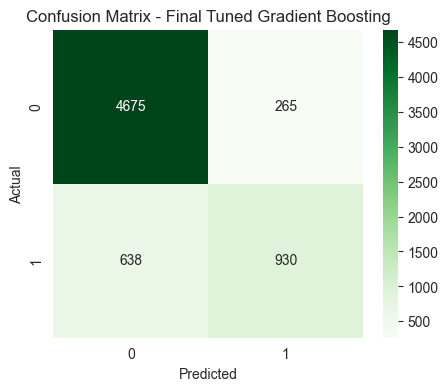

In [139]:
cm_final = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5,4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'Confusion Matrix - Final Tuned {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


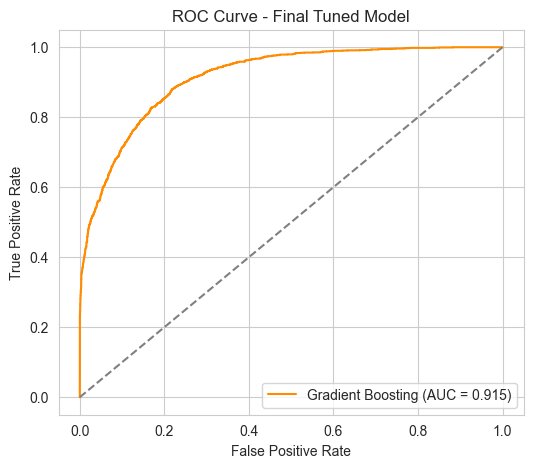

In [140]:
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {final_auc:.3f})', color='darkorange')
plt.plot([0,1],[0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Tuned Model')
plt.legend()
plt.show()


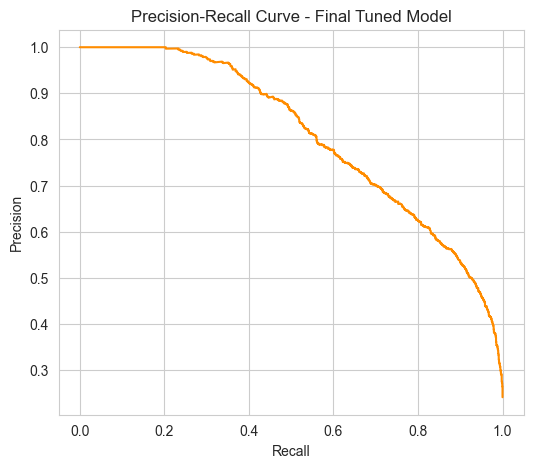

In [141]:
precision_f, recall_f, _ = precision_recall_curve(y_test, y_proba_final)
plt.figure(figsize=(6,5))
plt.plot(recall_f, precision_f, color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Final Tuned Model')
plt.show()


## Cell 18 - Feature Importance of Final Model

Checking which features the final tuned model relied on the most.

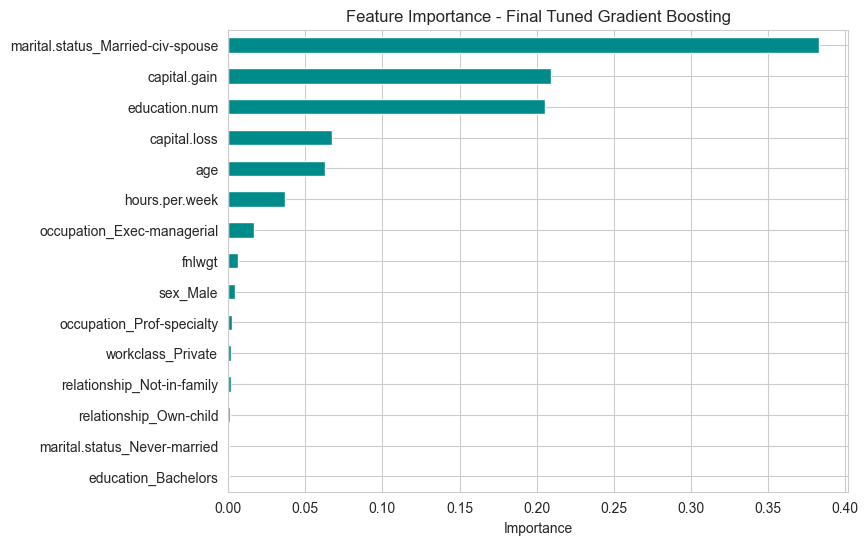

marital.status_Married-civ-spouse    0.382694
capital.gain                         0.209206
education.num                        0.205512
capital.loss                         0.067528
age                                  0.062566
hours.per.week                       0.036795
occupation_Exec-managerial           0.016589
fnlwgt                               0.006490
sex_Male                             0.004327
occupation_Prof-specialty            0.002387
workclass_Private                    0.002117
relationship_Not-in-family           0.001561
relationship_Own-child               0.001078
marital.status_Never-married         0.000858
education_Bachelors                  0.000291
dtype: float64


In [142]:
if hasattr(final_model, 'feature_importances_'):
    final_importance = pd.Series(final_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

    plt.figure(figsize=(8,6))
    final_importance.sort_values().plot(kind='barh', color='darkcyan')
    plt.title(f'Feature Importance - Final Tuned {best_model_name}')
    plt.xlabel('Importance')
    plt.show()

    print(final_importance)
else:
    print(f'{best_model_name} does not have a feature_importances_ attribute (this is normal for models like Logistic Regression, SVM, KNN and Naive Bayes).')


## Cell 19 - Conclusion

**Best Model:** The best performing model in this notebook was the one printed in Cell 15 (see `best_model_name`), after tuning with GridSearchCV / RandomizedSearchCV.

**Accuracy:** The final tuned model achieved the accuracy printed in Cell 17 (see `final_accuracy`), which is a good result for this dataset.

**Why it performed better:** Boosting and ensemble based models (like Gradient Boosting, AdaBoost, Random Forest) usually perform well on tabular data like this because they combine many weak learners and can capture non-linear relationships between features, unlike simpler models such as Logistic Regression or Naive Bayes which assume a simpler relationship between the features and the target.

**Most Important Features:** Based on Cell 18, features like `marital.status_Married-civ-spouse`, `capital.gain`, `education.num`, `age` and `hours.per.week` were among the most important in predicting income. This makes intuitive sense - people who are married, have higher education, work more hours and have capital gains tend to earn more.

**Future Improvements:**
- Try more advanced models like XGBoost or LightGBM.
- Do more feature engineering, for example combining `capital.gain` and `capital.loss` into a single net capital feature.
- Handle class imbalance using techniques like SMOTE, since the dataset has more `<=50K` samples than `>50K` samples.
- Try a wider hyperparameter search with more values and more cross-validation folds.
- Collect more recent data since this dataset is quite old (from the 1994 US Census).